In [47]:
# load csv files into pandas dataframes
import pandas as pd
import sqlite3
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


# Load the CSV files into pandas DataFrames
hospital_df = pd.read_csv('data/clean_data/cleaned_general_info.csv')
cehrt_df = pd.read_csv('data/clean_data/cleaned_cehrt.csv')
# Display the first few rows of each DataFrame
hospital_df.head(), cehrt_df.head()

(  facility_id                    facility_name   city_town state  zip_code  \
 0       10001  SOUTHEAST HEALTH MEDICAL CENTER      DOTHAN    AL     36301   
 1       10005         MARSHALL MEDICAL CENTERS        BOAZ    AL     35957   
 2       10006     NORTH ALABAMA MEDICAL CENTER    FLORENCE    AL     35630   
 3       10007         MIZELL MEMORIAL HOSPITAL         OPP    AL     36467   
 4       10011               ST. VINCENT'S EAST  BIRMINGHAM    AL     35235   
 
           hospital_type                           hospital_ownership  \
 0  Acute Care Hospitals  Government - Hospital District or Authority   
 1  Acute Care Hospitals  Government - Hospital District or Authority   
 2  Acute Care Hospitals                                  Proprietary   
 3  Acute Care Hospitals               Voluntary non-profit - Private   
 4  Acute Care Hospitals               Voluntary non-profit - Private   
 
    hospital_overall_rating  
 0                        3  
 1                      

Hospital DataFrame shape: (2806, 8)
CEHRT DataFrame shape: (4593, 4)
Top 10 EHR Developers:
developer_name
Epic Systems Corporation                           1633
Cerner Corporation                                  826
Inpriva, Inc.                                       297
Surescripts, LLC                                    220
Secure Exchange Solutions                           204
Imprivata                                           154
InterOperability Bidco, Inc., d.b.a. Rhapsody        87
Medical Information Technology, Inc. (MEDITECH)      71
MedAllies                                            70
DrFirst                                              63
Name: count, dtype: int64


/var/folders/df/tg69m9695r732006y9p547hm0000gn/T/ipykernel_12083/3870300978.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_developers.index, y=top_developers.values, palette='viridis')


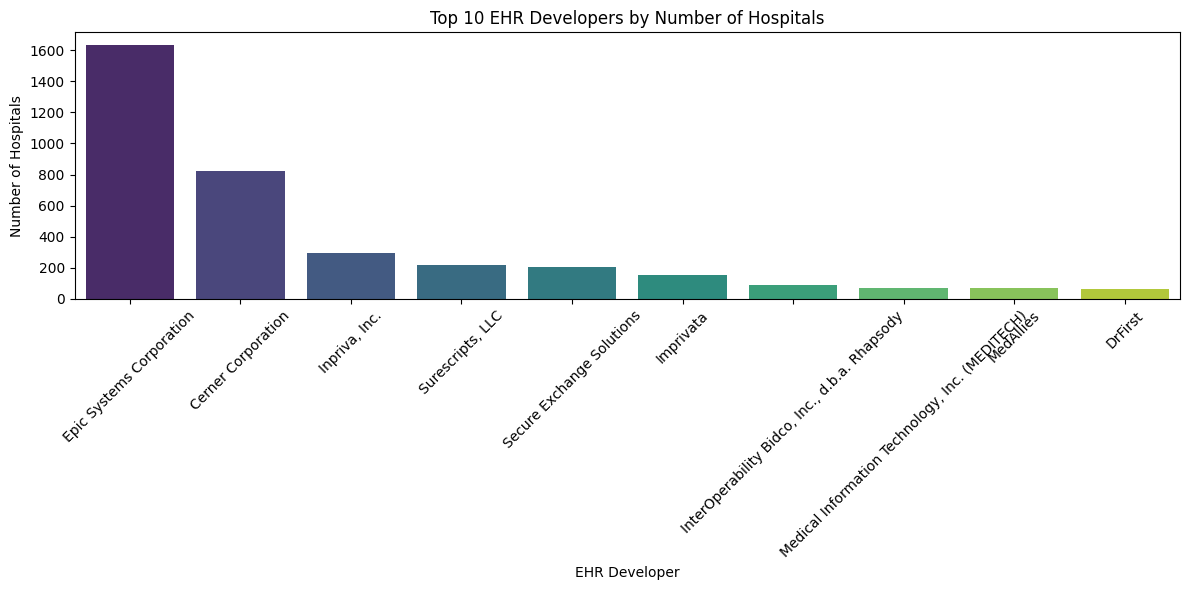

In [48]:
# print the shape of each DataFrame
print(f"Hospital DataFrame shape: {hospital_df.shape}")
print(f"CEHRT DataFrame shape: {cehrt_df.shape}")

#print top 10 most common EHR developers
top_developers = cehrt_df['developer_name'].value_counts().head(10)
print("Top 10 EHR Developers:")
print(top_developers)
#plot the top 10 EHR developers
plt.figure(figsize=(12, 6))
sns.barplot(x=top_developers.index, y=top_developers.values, palette='viridis')
plt.title('Top 10 EHR Developers by Number of Hospitals')
plt.xlabel('EHR Developer')
plt.ylabel('Number of Hospitals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#save the plot to plot folder
if not os.path.exists('plots'):
    os.makedirs('plots')
plt.savefig('plots/top_ehr_developers.png')
# Save the plot to a file
plt.savefig('plots/top_ehr_developers.png')
plt.close()

Unique EHR Developers: 45
Unique EHR Products: 70


/var/folders/df/tg69m9695r732006y9p547hm0000gn/T/ipykernel_12083/3353205817.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='developer_name', data=cehrt_df, order=cehrt_df['developer_name'].value_counts().index, palette='viridis')


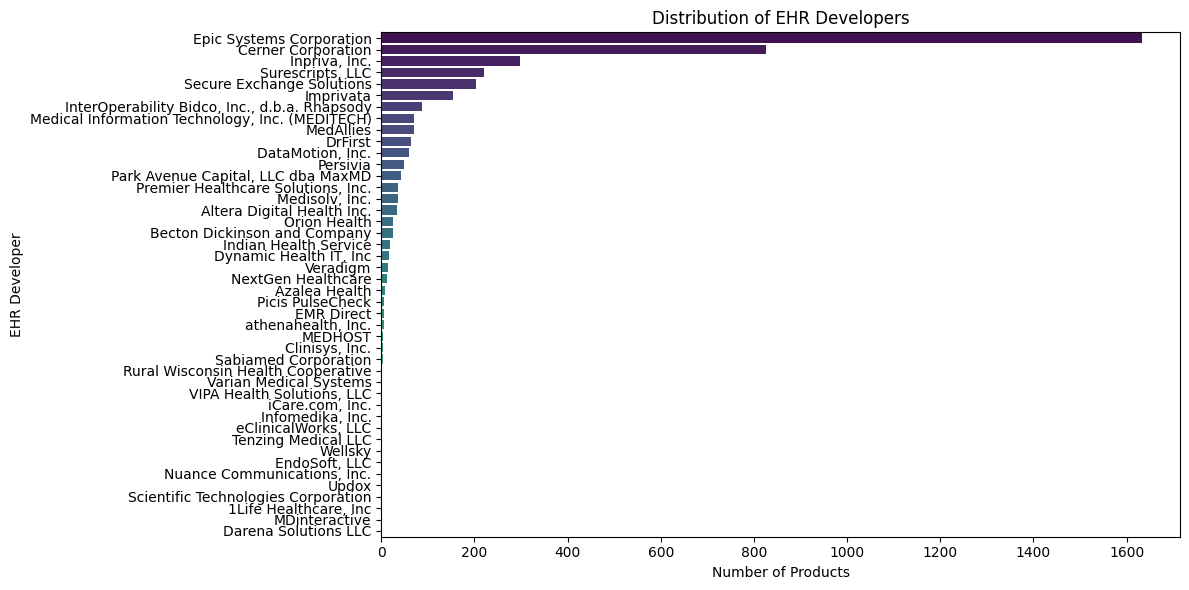

In [49]:
# print unique developer names and product names and visualize the distribution
unique_developers = cehrt_df['developer_name'].unique()
print(f"Unique EHR Developers: {len(unique_developers)}")
print(f"Unique EHR Products: {len(unique_products)}")   
# Visualize the distribution of EHR developers
plt.figure(figsize=(12, 6))
sns.countplot(y='developer_name', data=cehrt_df, order=cehrt_df['developer_name'].value_counts().index, palette='viridis')
plt.title('Distribution of EHR Developers')
plt.xlabel('Number of Products')
plt.ylabel('EHR Developer')
plt.tight_layout()
plt.savefig('plots/ehr_developer_distribution.png')

# Function to plot average hospital rating by EHR developer
def plot_avg_rating_by_developer(df, save_path):

    # Group by developer and calculate the average rating
    avg_rating = df.groupby('developer_name')['hospital_rating'].mean().sort_values(ascending=False)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    sns.barplot(x=avg_rating.index, y=avg_rating.values, palette='viridis')
    plt.title('Average Hospital Rating by EHR Developer')
    plt.xlabel('EHR Developer')
    plt.ylabel('Average Hospital Rating')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(save_path)
    plt.show()
plt.savefig('plots/avg_rating_by_developer.png')
__path__ = 'plots/avg_rating_by_developer.png'
# Call the function to plot and save the average rating by developer
